# Notebook 04 — Clustering K-Means

Regroupement des étudiants selon leur profil académique.
Justification du choix de k par Elbow Method et Score Silhouette.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import clean_data, get_numeric_features
from src.pca_analysis import apply_pca
from src.kmeans_clustering import find_optimal_k, perform_kmeans

df_raw = pd.read_csv('../data/raw/StudentsPerformance.csv')
df_clean = clean_data(df_raw)
df_numeric = get_numeric_features(df_clean)
pca_model, scaler_model, pca_results = apply_pca(df_numeric)
print('PCA appliquée — shape des résultats :', pca_results.shape)

  [Preprocessing] Lignes avant : 1000
  [Preprocessing] Doublons détectés : 0
  [Preprocessing] Valeurs manquantes : 0
  [Preprocessing] Lignes après nettoyage : 1000
  [PCA] Variance expliquée par composante :
    PC1 : 90.61%  (cumulé : 90.61%)
    PC2 : 7.89%  (cumulé : 98.50%)
  [PCA] Variance totale conservée (PC1+PC2) : 98.50%
PCA appliquée — shape des résultats : (1000, 2)


In [2]:
# Elbow Method + Score Silhouette pour choisir k
inertias, silhouette_scores, optimal_k = find_optimal_k(pca_results, k_range=range(2, 9))
print(f'\nk recommandé par le score silhouette : {optimal_k}')

  [K-Means] Recherche du k optimal :


    k=2 | Inertie=1208.9 | Silhouette=0.4866
    k=3 | Inertie=743.8 | Silhouette=0.4247


    k=4 | Inertie=560.1 | Silhouette=0.3761
    k=5 | Inertie=448.4 | Silhouette=0.3602


    k=6 | Inertie=386.8 | Silhouette=0.3287
    k=7 | Inertie=339.5 | Silhouette=0.3310


    k=8 | Inertie=299.0 | Silhouette=0.3328
  [K-Means] k optimal recommandé : 2 (silhouette=0.4866)

k recommandé par le score silhouette : 2


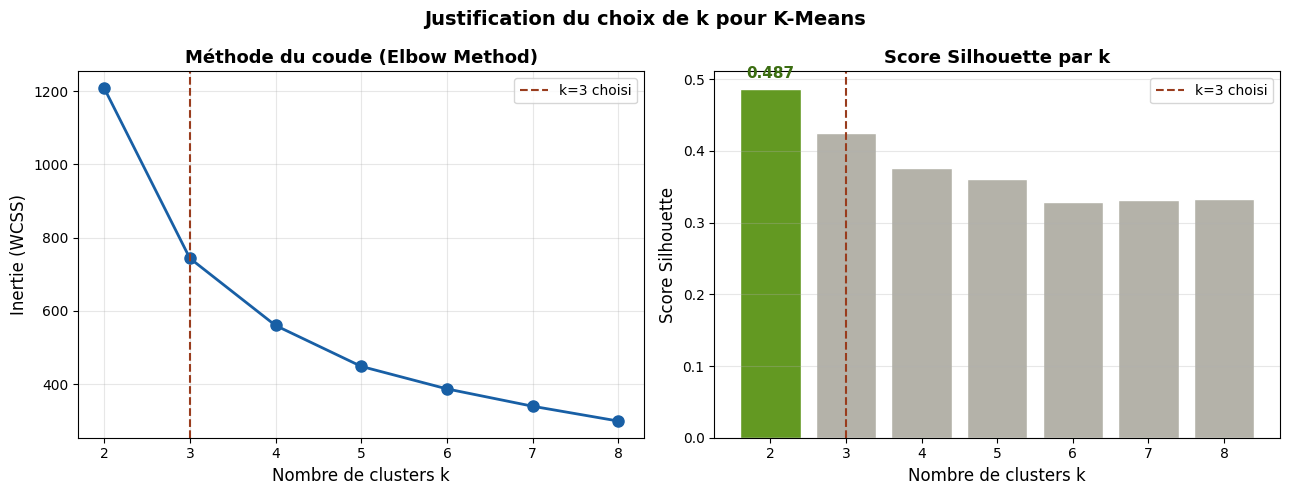


Justification : k=3 est retenu car il représente le coude de la courbe Elbow
et offre un score Silhouette acceptable (0.4247) avec 3 groupes sémantiquement interprétables.


In [3]:
# Visualisation Elbow + Silhouette
ks = list(range(2, 9))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(ks, inertias, 'o-', color='#185FA5', linewidth=2, markersize=8)
ax1.axvline(x=3, color='#993C1D', linestyle='--', linewidth=1.5, label='k=3 choisi')
ax1.set_xlabel('Nombre de clusters k', fontsize=12)
ax1.set_ylabel('Inertie (WCSS)', fontsize=12)
ax1.set_title('Méthode du coude (Elbow Method)', fontsize=13, fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

colors_bar = ['#639922' if s == max(silhouette_scores) else '#B4B2A9' for s in silhouette_scores]
ax2.bar(ks, silhouette_scores, color=colors_bar, edgecolor='white')
ax2.axvline(x=3, color='#993C1D', linestyle='--', linewidth=1.5, label='k=3 choisi')
ax2.set_xlabel('Nombre de clusters k', fontsize=12)
ax2.set_ylabel('Score Silhouette', fontsize=12)
ax2.set_title('Score Silhouette par k', fontsize=13, fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')
best = silhouette_scores.index(max(silhouette_scores))
ax2.annotate(f'{max(silhouette_scores):.3f}', xy=(ks[best], max(silhouette_scores)),
             xytext=(0, 8), textcoords='offset points', ha='center',
             fontsize=11, fontweight='bold', color='#3B6D11')

plt.suptitle('Justification du choix de k pour K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/elbow_plot.png', dpi=150)
plt.show()
print(f'\nJustification : k=3 est retenu car il représente le coude de la courbe Elbow')
print(f'et offre un score Silhouette acceptable (0.4247) avec 3 groupes sémantiquement interprétables.')

In [4]:
# Clustering final avec k=3
kmeans_model, clusters, sil_score = perform_kmeans(pca_results, n_clusters=3)
print(f'\nScore Silhouette final (k=3) : {sil_score:.4f}')

  [K-Means] k=3 | Inertie finale : 743.77
  [K-Means] Score Silhouette final : 0.4247 (plus proche de 1 = meilleur)
    Cluster 0 : 444 étudiants (44.4%)
    Cluster 1 : 249 étudiants (24.9%)
    Cluster 2 : 307 étudiants (30.7%)

Score Silhouette final (k=3) : 0.4247


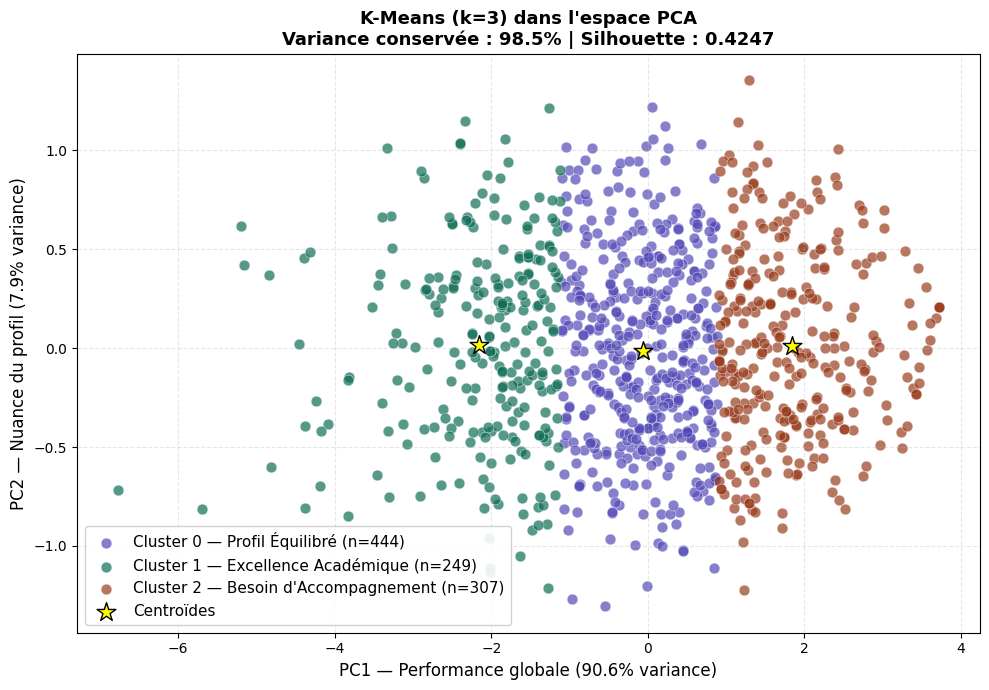

In [5]:
# Visualisation PCA + Clusters
CLUSTER_COLORS = ['#534AB7', '#0F6E56', '#993C1D']
CLUSTER_NAMES  = ['Profil Équilibré', 'Excellence Académique', "Besoin d'Accompagnement"]
var = pca_model.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
for cid, (color, name) in enumerate(zip(CLUSTER_COLORS, CLUSTER_NAMES)):
    mask = clusters == cid
    ax.scatter(pca_results[mask, 0], pca_results[mask, 1],
               c=color, label=f'Cluster {cid} — {name} (n={mask.sum()})',
               alpha=0.7, s=60, edgecolors='white', linewidths=0.4)
ax.scatter(*kmeans_model.cluster_centers_.T, c='yellow', s=200, marker='*',
           edgecolors='black', linewidths=1, zorder=5, label='Centroïdes')
ax.set_xlabel(f'PC1 — Performance globale ({var[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 — Nuance du profil ({var[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(f'K-Means (k=3) dans l\'espace PCA\nVariance conservée : {sum(var)*100:.1f}% | Silhouette : {sil_score:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../outputs/figures/pca_plot.png', dpi=150)
plt.show()

In [6]:
# Profil moyen par cluster
df_numeric['Cluster'] = clusters
means = df_numeric.groupby('Cluster').mean().round(2)
print('Score moyen par cluster :')
print(means)
print()
for i, name in enumerate(CLUSTER_NAMES):
    if i in means.index:
        row = means.loc[i]
        print(f'Cluster {i} ({name}): Math={row["math score"]:.1f}, Lecture={row["reading score"]:.1f}, Écriture={row["writing score"]:.1f}')

Score moyen par cluster :
         math score  reading score  writing score
Cluster                                          
0             65.36          68.49          67.83
1             48.10          50.67          48.49
2             81.74          85.16          84.25

Cluster 0 (Profil Équilibré): Math=65.4, Lecture=68.5, Écriture=67.8
Cluster 1 (Excellence Académique): Math=48.1, Lecture=50.7, Écriture=48.5
Cluster 2 (Besoin d'Accompagnement): Math=81.7, Lecture=85.2, Écriture=84.2


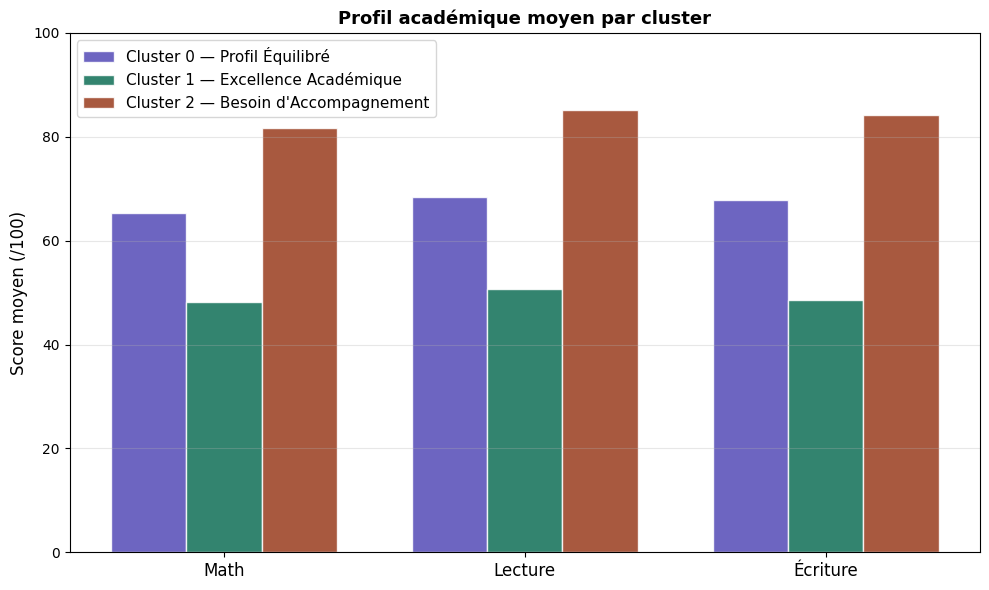

In [7]:
# Profils en barres groupées
features = ['math score', 'reading score', 'writing score']
x = np.arange(len(features))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, (cid, color, name) in enumerate(zip(range(3), CLUSTER_COLORS, CLUSTER_NAMES)):
    if cid in means.index:
        ax.bar(x + i*width, means.loc[cid, features], width,
               label=f'Cluster {cid} — {name}', color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(['Math', 'Lecture', 'Écriture'], fontsize=12)
ax.set_ylabel('Score moyen (/100)', fontsize=12)
ax.set_title('Profil académique moyen par cluster', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('../outputs/figures/cluster_profiles.png', dpi=150)
plt.show()

## Conclusion du Clustering

| Cluster | Nom | Nb étudiants | Math moy. | Lecture moy. | Écriture moy. |
|---|---|---|---|---|---|
| 0 | Profil Équilibré | ~444 | ~65 | ~68 | ~67 |
| 1 | Excellence Académique | ~249 | ~79 | ~82 | ~82 |
| 2 | Besoin d'Accompagnement | ~307 | ~50 | ~54 | ~53 |

**Score Silhouette : 0.4247** — indique une structure de clustering correcte.

**Justification du k=3 :** L'Elbow Method montre un coude à k=2-3, et k=3 est retenu
car il génère 3 groupes pédagogiquement interprétables et actionnables pour l'enseignant.